# Brownian motion

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import scienceplots
plt.style.use('science')
import numpy as np
from numpy.random import rand
import matplotlib as mpl
np.seed = 123
import math

## Symmetric random walk

Let $S$ be a symmetric random walk, that is

$$
P(S_{n+1} = s + 1 / S_n = s) = p
$$

$$
P(S_{n+1} = s - 1 / S_n = s) = 1 - p = q
$$

In [2]:
# x is the starting point and he walker advance with a probability of prob
def next_step(x, prob):
    if (rand() < prob):
        return x + 1
    else:
        return x - 1

In [3]:
# k is the starting point of the random walker
def random_walk(N, k = 0, prob = 0.5):
    steps = np.zeros(N, dtype = np.int64)
    steps[0] = k
    for i in range(1, N):
        steps[i] = next_step(steps[i-1], prob)
    return steps

In [4]:
n = 1000
s = random_walk(n)

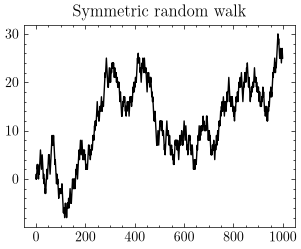

In [9]:
plt.plot(s, color = "black")
plt.title("Symmetric random walk")
plt.show()

## Continuous random walk

In [10]:
def continuous_random_walk(x, T, n, delta):
    deltat = T / n
    m = x.size
    y = []
    t = 0.
    while (math.floor(t / deltat) < m):
        y.append(math.sqrt(deltat) * x[math.floor(t / deltat)])
        t += deltat
    return np.array(y)

In [11]:
x = continuous_random_walk(s, 1, 10, 0.1)

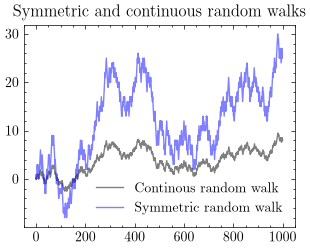

In [12]:
plt.plot(x, color = "black", alpha = .5, label = "Continous random walk")
plt.plot(s, color = "blue", alpha = .5, label = "Symmetric random walk")
plt.title("Symmetric and continuous random walks")
plt.legend()
plt.show()

## Different $\Delta_t$

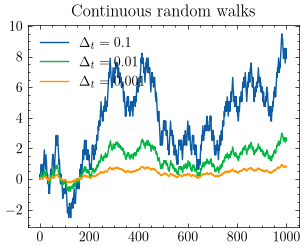

In [13]:
plt.plot(continuous_random_walk(s, 1, 10, 0.1), label = r"$\Delta_t = 0.1$")
plt.plot(continuous_random_walk(s, 1, 100, 0.1), label = r"$\Delta_t = 0.01$")
plt.plot(continuous_random_walk(s, 1, 1000, 0.1), label = r"$\Delta_t = 0.001$")
plt.title("Continuous random walks")
plt.legend()
plt.show()

## Brownian motion / Donker's invariance principle

In [14]:
def brownian_motion(s, T):
    deltat = 1. / T
    s = s.cumsum()
    n = s.size
    w = []
    t = 0.
    i = 0
    while math.floor(n*t) < n:
        w.append(s[math.floor(n*t)] * math.sqrt(deltat) / math.sqrt(n))
        t += deltat
    return np.array(w)

In [16]:
w = brownian_motion(s, n)

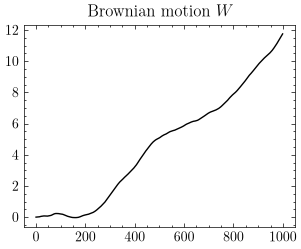

In [18]:
plt.plot(w, color = "black")
plt.title(r"Brownian motion $W$")
plt.show()

In [19]:
def diff(w):
    diffw = np.zeros(w.size - 1)
    for i in range(diffw.size):
        diffw[i] = w[i+1] - w[i]
    return diffw

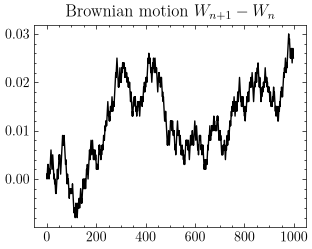

In [21]:
# Check that the difference is in [-1, 1]
diffw = diff(w)
plt.plot(diffw, color = "black")
plt.title("Brownian motion $W_{n+1}-W_{n}$")
plt.show()

## Paths and limit

In [22]:
# Save paths into W[n,t]
n = 1000
T = 100
W = np.zeros((n, T))
for i in range(n):
    S = random_walk(n)
    W[i, :] = brownian_motion(S, T)

## Central limit theorem

**Expectation and variance**

In [23]:
E = np.zeros(T)
V = np.zeros(T)
for i in range(T):
    E[i] = W[:, i].mean()
    V[i] = W[:, i].var()

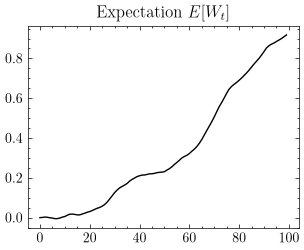

In [24]:
plt.plot(E, color = "black")
plt.title(r"Expectation $E[W_t]$")
plt.show()

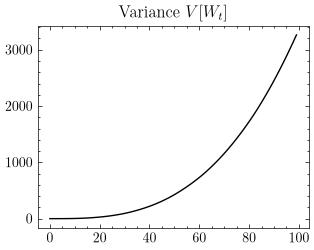

In [25]:
plt.plot(V, color = "black")
plt.title(r"Variance $V[W_t]$")
plt.show()

**Density / Histograms**

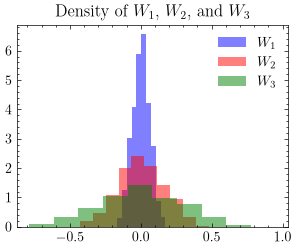

In [26]:
plt.hist(W[:, 1], density = True, color = "blue", alpha = .5, label = r"$W_1$")
plt.hist(W[:, 2], density = True, color = "red", alpha = .5, label = r"$W_2$")
plt.hist(W[:, 3], density = True, color = "green", alpha = .5, label = r"$W_3$")
plt.title(r"Density of $W_1$, $W_2$, and $W_3$")
plt.legend()
plt.show()